In [1]:
# import necessary packages
import cmapPy.pandasGEXpress.GCToo as GCToo
import pandas as pd
from cmapPy.pandasGEXpress.parse import parse
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

#### *1. Select the 978 landmark gene ids to extract from .gctx file*

In [2]:
# read gene info from gene_info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [3]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### *2. Filter out only the trt_cp data using GSE70138_Broad_LINCS_sig_info.txt and save into trt_cps_sig_info.txt with the command line:*
``` bash
grep trt_cp GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > column_names_sig_info.txt
cat column_names_sig_info.txt trt_cps.txt > trt_cps_sig_info.txt
rm column_names_sig_info.txt trt_cps.txt
```

#### *3. Extract trt_cps and save as TAS_trt_cps.txt using the following command:*
```bash
grep trt_cp GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt | cut -f2,5-6,8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt | cut -f2,5-6,8 > column_names_sig_metrics.txt
cat column_names_sig_metrics.txt trt_cps.txt > TAS_trt_cps.txt
rm column_names_sig_metrics.txt trt_cps.txt
```

## Select the gene signatures ids of compounds of interest

#### *1. Select all gene signature info with MCF7*

In [4]:
# read the gene signature info
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/trt_cps_sig_info.txt"
sig_info = pd.read_csv(file_path, sep="\t", dtype=str)
sig_info.set_index("sig_id", inplace=True)

In [5]:
# select only the gene signature ids with MCF7
MCF7_sig_info = sig_info[sig_info['cell_id'] == 'MCF7']
MCF7_sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...


In [6]:
# total number of gene signatures
len(MCF7_sig_info)

12737

#### *2. From these gene signatures, select only those with very high transcriptional responses (TAS > 0.6)*

##### a. Add the TAS scores to the sig_id info

In [7]:
# read the TAS scores of the gene signatures
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/TAS_trt_cps.txt"
tas_trt_cps = pd.read_csv(file_path, sep="\t", dtype=str)
tas_trt_cps.set_index('sig_id', inplace=True)
tas_trt_cps.head()

,pert_id,pert_iname,tas
sig_id,,,
REP.A001_A375_24H:A07,BRD-K25114078,aminoguanidine,0.111322
REP.A001_A375_24H:A08,BRD-K25114078,aminoguanidine,0.104451
REP.A001_A375_24H:A09,BRD-K25114078,aminoguanidine,0.113235
REP.A001_A375_24H:A10,BRD-K25114078,aminoguanidine,0.0747183
REP.A001_A375_24H:A11,BRD-K25114078,aminoguanidine,0.107109


In [8]:
# add the TAS scores to the sig_info for MCF7
MCF7_trt_cps = MCF7_sig_info.merge(tas_trt_cps, on=['sig_id', 'pert_id','pert_iname'], how='inner')
MCF7_trt_cps.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...,0.207429
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...,0.303676
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...,0.231824
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...,0.109656
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...,0.244196


In [9]:
# total of number of compounds with tas scores
len(MCF7_trt_cps)

10581

##### b. Sort TAS scores in descending order and select only those where TAS > 0.6

In [11]:
# sort the TAS scores in descending order
top_trt_cps = MCF7_trt_cps.sort_values(by='tas', ascending=False)
top_trt_cps['tas'] = top_trt_cps['tas'].astype(float)

# select only the ones with very high response (TAS > 0.6)
high_tas_trt_cps = top_trt_cps[top_trt_cps['tas'] > 0.6]

# check that the table ends at 0.6
high_tas_trt_cps.tail(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A024_MCF7_24H:E09,BRD-A74914197,pralatrexate,MCF7,1.11 um,24 h,REP.A024_MCF7_24H_X1_B23:E09|REP.A024_MCF7_24H...,0.604770
REP.A004_MCF7_24H:I23,BRD-K23363278,CYT-997,MCF7,0.12 um,24 h,REP.A004_MCF7_24H_X1_B27:I23|REP.A004_MCF7_24H...,0.604288
REP.A002_MCF7_24H:K19,BRD-K17705806,JTC-801,MCF7,10.0 um,24 h,REP.A002_MCF7_24H_X1_B27:K19|REP.A002_MCF7_24H...,0.604279
REP.A003_MCF7_24H:A19,BRD-K23499943,alvespimycin,MCF7,10.0 um,24 h,REP.A003_MCF7_24H_X1_B27:A19|REP.A003_MCF7_24H...,0.604228
REP.A023_MCF7_24H:H09,BRD-K69776681,volasertib,MCF7,1.11 um,24 h,REP.A023_MCF7_24H_X1_B23:H09|REP.A023_MCF7_24H...,0.603907
REP.A027_MCF7_24H:D22,BRD-K93779381,ingenol-mebutate,MCF7,0.37 um,24 h,REP.A027_MCF7_24H_X1_B25:D22|REP.A027_MCF7_24H...,0.603704
REP.A008_MCF7_24H:C02,BRD-K36740062,GSK-1070916,MCF7,3.33 um,24 h,REP.A008_MCF7_24H_X1_B24:C02|REP.A008_MCF7_24H...,0.603602
REP.A002_MCF7_24H:K07,BRD-K60230970,MG-132,MCF7,20.0 um,24 h,REP.A002_MCF7_24H_X1_B27:K07|REP.A002_MCF7_24H...,0.601651
LJP008_MCF7_24H:I07,BRD-K16485616,mocetinostat,MCF7,10.0 um,24 h,LJP008_MCF7_24H_X1_B20:I07|LJP008_MCF7_24H_X2_...,0.600766


## Check the gene signatures of bortezimib of MCF7 cell line

In [13]:
# from the MCF7 gene sig info with high TAS scores (all gene info w/ bortezimib), 
# select only those with bortezimib
bortezimib_gene_info = high_tas_trt_cps[high_tas_trt_cps['pert_iname'] == 'bortezomib']

# check that you have all the samples
bortezimib_gene_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A020_MCF7_24H:G13,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:G13|REP.A020_MCF7_24H...,0.826145
REP.A008_MCF7_24H:C22,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A008_MCF7_24H_X1_B24:C22|REP.A008_MCF7_24H...,0.815444
REP.A020_MCF7_24H:C22,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:C22|REP.A020_MCF7_24H...,0.811573
REP.A015_MCF7_24H:C23,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A015_MCF7_24H_X1_B23:C23|REP.A015_MCF7_24H...,0.811346
REP.A020_MCF7_24H:C23,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:C23|REP.A020_MCF7_24H...,0.809700


## Map the drugs to the diseases

The diseases related to each drug was taken from the Broad Institute:
https://repo-hub.broadinstitute.org/repurposing#download-data

In [14]:
# import the disease information for each drug
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/repurposing_drugs_20200324.txt'
disease_info = pd.read_csv(file_path, sep="\t", dtype=str, skiprows=9)

# set the index as the name of the compound
disease_info.set_index('pert_iname', inplace=True)
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
(R)-(-)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4A|PDE4B|PDE4C|PDE4D|PDE5A,NaN,NaN
(R)-baclofen,Phase 3,benzodiazepine receptor agonist,GABBR1|GABBR2,NaN,NaN
(S)-(+)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4B|PDE4D,NaN,NaN
"[sar9,met(o2)11]-substance-p",Preclinical,tachykinin antagonist,TACR1,NaN,NaN


In [15]:
# remove pert_inames where there is no indication (NaN)
disease_info = disease_info[disease_info['indication'].notna()]
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
abacavir,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abamectin,Launched,benzodiazepine receptor agonist,GABBR1|GABBR2,infectious disease,gastrointestinal parasites
abemaciclib,Launched,CDK inhibitor,CDK4|CDK6,oncology,breast cancer
abiraterone,Launched,androgen biosynthesis inhibitor,CYP11B1|CYP17A1,oncology,prostate cancer


In [16]:
# obtain the pert_info data
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_pert_info.txt'
pert_info = pd.read_csv(file_path, sep="\t", dtype=str)

# set the index of the dataframe as the pert_iname
pert_info.set_index('pert_iname', inplace=True)
pert_info.head()

,pert_id,canonical_smiles,inchi_key,pert_type
pert_iname,,,,
10-DEBC,BRD-K70792160,CCN(CC)CCCCN1c2ccccc2Oc2ccc(Cl)cc12,GYBXAGDWMCJZJK-UHFFFAOYSA-N,trt_cp
phorbol-myristate-acetate,BRD-K68552125,CCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](C)[C@]2(O)[C@...,PHEDXBVPIONUQT-RGYGYFBISA-N,trt_cp
"16,16-dimethylprostaglandin-e2",BRD-K92301463,CCCCC(C)(C)[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C...,QAOBBBBDJSWHMU-WMBBNPMCSA-N,trt_cp
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp
2-iminobiotin,BRD-K07954936,OC(=O)CCCC[C@@H]1SC[C@@H]2NC(=N)N[C@H]12,WWVANQJRLPIHNS-ZKWXMUAHSA-N,trt_cp


In [17]:
# select only the drugs associated with a disease
drug_to_disease = pert_info.merge(disease_info, how='inner', on='pert_iname')
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp,Launched,progesterone receptor agonist,AR|ESR1|ESR2|NR1H4|NR1I2|NR3C1|PGR,obstetrics/gynecology,spontaneous preterm birth
5-aminolevulinic-acid,BRD-K57631554,NCC(=O)CCC(O)=O,ZGXJTSGNIOSYLO-UHFFFAOYSA-N,trt_cp,Launched,oxidizing agent,ALAD,oncology|dermatology,glioma|actinic keratosis (AK)
abacavir,BRD-A95032015,Nc1nc(NC2CC2)c2ncn(C3C[C@H](CO)C=C3)c2n1,MCGSCOLBFJQGHM-HNHGDDPOSA-N,trt_cp,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abiraterone-acetate,BRD-K16133773,CC(=O)O[C@H]1CC[C@]2(C)[C@@H]3CC[C@@]4(C)[C@@H...,UVIQSJCZCSLXRZ-HCWFNAMGSA-N,trt_cp,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acarbose,BRD-K01621533,C[C@@H]1O[C@H](O[C@@H]2[C@H](CO)O[C@H](O[C@@H]...,XUFXOAAUWZOOIT-PCKYEMPFSA-N,trt_cp,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [18]:
# calculate the total number of drugs associated with a disease
len(drug_to_disease)

884

In [19]:
# sort the drugs by their disease area and disease indication
drug_to_disease = drug_to_disease.sort_values(by=['disease_area', 'indication'])
drug_to_disease.head(10)

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
acrivastine,BRD-K50163129,Cc1ccc(cc1)C(=C/CN1CCCC1)\c1cccc(\C=C\C(O)=O)n1,PWACSDKDOHSSQD-IUTFFREVSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
beclomethasone-dipropionate,BRD-A11319535,CCC(=O)OCC(=O)C1(OC(=O)CC)C(C)CC2C3CCC4=CC(=O)...,KUVIULQEHSCUHY-UHFFFAOYSA-N,trt_cp,Launched,glucocorticoid receptor agonist,GPR97|NR3C1,allergy,allergic rhinitis
ciclesonide,BRD-K35245662,CC(C)C(=O)OCC(=O)[C@@]12O[C@@H](O[C@@H]1C[C@H]...,LUKZNWIVRBCLON-GXOBDPJESA-N,trt_cp,Launched,glucocorticoid receptor agonist,NR3C1|SERPINA6,allergy,allergic rhinitis
clemizole,BRD-K04704168,Clc1ccc(Cn2c(CN3CCCC3)nc3ccccc23)cc1,CJXAEXPPLWQRFR-UHFFFAOYSA-N,trt_cp,Launched,HCV inhibitor,NaN,allergy,allergic rhinitis
diphenylpyraline,BRD-K22936972,CN1CCC(CC1)OC(c1ccccc1)c1ccccc1,OWQUZNMMYNAXSL-UHFFFAOYSA-N,trt_cp,Launched,dopamine reuptake inhibitor,HRH1|SLC6A3,allergy,allergic rhinitis
histamine,BRD-K01674964,NCCc1c[nH]cn1,NTYJJOPFIAHURM-UHFFFAOYSA-N,trt_cp,Launched,histamine receptor agonist,HRH1|HRH2|HRH3|HRH4,allergy,allergic rhinitis
homochlorcyclizine,BRD-A22769835,CN1CCCN(CC1)C(c1ccccc1)c1ccc(Cl)cc1,WEUCDJCFJHYFRL-UHFFFAOYSA-N,trt_cp,Launched,antihistamine,HRH1,allergy,allergic rhinitis
oxatomide,BRD-K02079473,O=c1[nH]c2ccccc2n1CCCN1CCN(CC1)C(c1ccccc1)c1cc...,BAINIUMDFURPJM-UHFFFAOYSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
chlorphenamine,BRD-A04553218,CN(C)CCC(c1ccc(Cl)cc1)c1ccccn1,SOYKEARSMXGVTM-UHFFFAOYSA-N,trt_cp,Launched,histamine receptor antagonist,NaN,allergy,allergic rhinitis|urticaria


## Select drugs to compare based on these disease indications

#### *1. Show only the compounds that have high TAS scores with a drug indication*

In [20]:
# select all the samples with high TAS scores treated with MCF7 that have a disease associated with it
test_samples = high_tas_trt_cps[high_tas_trt_cps['pert_iname'].isin(drug_to_disease.index)]

# unique compounds with associated diseases
cp_names = test_samples['pert_iname'].unique()

In [21]:
cp_names

array(['bortezomib', 'altrenogest', 'epirubicin', 'mepacrine',
       'midostaurin', 'homoharringtonine', 'romidepsin', 'valrubicin',
       'daunorubicin', 'carfilzomib', 'tioconazole', 'digoxin',
       'doxorubicin', 'floxuridine', 'niclosamide', 'vorinostat',
       'lomitapide', 'podophyllotoxin', 'dabigatran-etexilate',
       'mebendazole', 'mitoxantrone', 'belinostat', 'crizotinib',
       'lacidipine', 'amsacrine', 'penfluridol', 'tioguanine',
       'azacitidine', 'albendazole', 'pralatrexate', 'sirolimus',
       'etravirine', 'metronidazole', 'ifosfamide', 'tizanidine',
       'ingenol-mebutate', 'thioguanine'], dtype=object)

In [22]:
# number of unique compounds with associated diseases
len(cp_names)

37

#### *2. Select the 3 compounds to compare to each other*

In [23]:
# list the indication of these compounds
drug_to_disease['indication'][drug_to_disease.index.isin(cp_names)]

pert_iname
digoxin                 congestive heart failure|atrial fibrillation (AF)
lacidipine                                                   hypertension
ingenol-mebutate                                   actinic keratosis (AK)
metronidazole                                                     rosacea
altrenogest                                                        estrus
lomitapide                                           hypercholesterolemia
amsacrine                              acute lymphoblastic leukemia (ALL)
midostaurin                                  acute myeloid leukemia (AML)
thioguanine                                  acute myeloid leukemia (AML)
daunorubicin            acute myeloid leukemia (AML)|acute lymphoblast...
tioguanine              acute myeloid leukemia (AML)|acute lymphoblast...
homoharringtonine                          chronic myeloid leukemia (CML)
romidepsin                               cutaneous T-cell lymphoma (CTCL)
vorinostat                 

From this list, lets compare midostaurin and thioguanine (targeting acute myeloid leukemia) to penfluridol (schizophrenia) using Spearman correlation

In [24]:
# looking at azacitidine since it appears 2x --> bc there are two different pert_ids
drug_to_disease.loc['azacitidine']

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
azacitidine,BRD-K55026842,Nc1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@@H]2O)c(=O)n1,NMUSYJAQQFHJEW-ARQDHWQXSA-N,trt_cp,Launched,DNA methyltransferase inhibitor,DNMT1|DNMT3A,hematologic malignancy|hematology,myelodysplastic diseases (MDS)|anemia|chronic ...
azacitidine,BRD-K03406345,Nc1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)n1,NMUSYJAQQFHJEW-KVTDHHQDSA-N,trt_cp,Launched,DNA methyltransferase inhibitor,DNMT1|DNMT3A,hematologic malignancy|hematology,myelodysplastic diseases (MDS)|anemia|chronic ...


#### *3. Select the relevant data for the 3 compounds to compare to each other*

In [25]:
# list of compounds to compare
trt_cps = ['midostaurin', 'thioguanine', 'penfluridol']

In [26]:
# select the sig_info for these three compounds
test_cps_sig_info = high_tas_trt_cps[high_tas_trt_cps['pert_iname'].isin(trt_cps)]
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A010_MCF7_24H:I02,BRD-K13646352,midostaurin,MCF7,3.33 um,24 h,REP.A010_MCF7_24H_X1_B24:I02|REP.A010_MCF7_24H...,0.799386
REP.A010_MCF7_24H:I01,BRD-K13646352,midostaurin,MCF7,10.0 um,24 h,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H...,0.794343
REP.A010_MCF7_24H:P13,BRD-K15409150,penfluridol,MCF7,10.0 um,24 h,REP.A010_MCF7_24H_X1_B24:P13|REP.A010_MCF7_24H...,0.659227
REP.A019_MCF7_24H:K19,BRD-K49350383,thioguanine,MCF7,10.0 um,24 h,REP.A019_MCF7_24H_X1_B23:K19|REP.A019_MCF7_24H...,0.617237


As can be seen from this data, only 4 samples total. There is only one set of samples that is dosed at 10.0 um so only this dosage will be used for spearman correlation.

In [27]:
# remove the first sample from analysis
test_cps_sig_info = test_cps_sig_info[1:]
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A010_MCF7_24H:I01,BRD-K13646352,midostaurin,MCF7,10.0 um,24 h,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H...,0.794343
REP.A010_MCF7_24H:P13,BRD-K15409150,penfluridol,MCF7,10.0 um,24 h,REP.A010_MCF7_24H_X1_B24:P13|REP.A010_MCF7_24H...,0.659227
REP.A019_MCF7_24H:K19,BRD-K49350383,thioguanine,MCF7,10.0 um,24 h,REP.A019_MCF7_24H_X1_B23:K19|REP.A019_MCF7_24H...,0.617237


In [28]:
# store the sig ids of these compounds
test_cps_sig_ids = test_cps_sig_info.index

#### *4. Select the gene signatures for selected compounds*

In [29]:
# defining function to select relevant data at one dose
def select_dose(sig_info, dose):
    select_dose_sig_info = sig_info[sig_info["pert_idose"] == dose]
    return select_dose_sig_info

In [30]:
# obtain all the different dosages
pert_idoses = test_cps_sig_info["pert_idose"].unique()

# initialize a list to store all the gene signatures and sig info for each dose in pert_idose
sig_infos = []

In [31]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# separate gene signatures by each dose in pert_idose
for dose in pert_idoses:
    # select gene signatures of one dose
    dose_sig_info = select_dose(test_cps_sig_info, dose)
    
    # select the gene signature ids
    dose_sig_ids = dose_sig_info.index
    
    # select only the landmark genes of drug compounds of interest
    dose_gene_sigs = parse(file_path, rid=lm_gene_id, cid=dose_sig_ids)
    
    # create a new GCTOO object that contains the sig_info as the columns and gene_sigs as rows
    sig_info = GCToo.GCToo(data_df=dose_gene_sigs.data_df.copy(), 
                                              row_metadata_df=dose_gene_sigs.row_metadata_df.copy(), 
                                              col_metadata_df=dose_sig_info, 
                                             make_multiindex=True)
    
    # store sig_info
    sig_infos.append(sig_info)

In [32]:
# snapshot of what each dataset looks like for each dose
sig_infos[0].multi_index_df[:5]

pert_id,BRD-K13646352,BRD-K15409150,BRD-K49350383
pert_iname,midostaurin,penfluridol,thioguanine
cell_id,MCF7,MCF7,MCF7
pert_idose,10.0 um,10.0 um,10.0 um
pert_itime,24 h,24 h,24 h
distil_id,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H_X2_B24:I01|REP.A010_MCF7_24H_X3_B24:I01,REP.A010_MCF7_24H_X1_B24:P13|REP.A010_MCF7_24H_X2_B24:P13|REP.A010_MCF7_24H_X3_B24:P13,REP.A019_MCF7_24H_X1_B23:K19|REP.A019_MCF7_24H_X2_B24:K19|REP.A019_MCF7_24H_X3_B23:K19
tas,0.794343,0.659227,0.617237
cid,REP.A010_MCF7_24H:I01,REP.A010_MCF7_24H:P13,REP.A019_MCF7_24H:K19
rid,,,
0,1.669526,3.164559,-1.283763
1,3.920308,-0.445096,0.038814


## Perform Spearman correlation

In [33]:
# function to create a scatter plot for each drug dosage comparing 2 drug compounds
def spearman_correlation(sig_infos, col1_idx, col2_idx):
    for dose_sig_info in sig_infos:
        plt.figure()
        # make a scatterplot 
        sns.scatterplot(
            x = dose_sig_info.data_df.iloc[:, col1_idx],
            y = dose_sig_info.data_df.iloc[:, col2_idx]
        )
        plt.xlabel(dose_sig_info.col_metadata_df.iloc[col1_idx].pert_iname)
        plt.ylabel(dose_sig_info.col_metadata_df.iloc[col2_idx].pert_iname)
        plt.title(dose_sig_info.col_metadata_df.iloc[col1_idx].pert_idose)
        plt.show()

        # perform a spearman correlation
        print(stats.spearmanr(dose_sig_info.data_df.iloc[:, col1_idx], dose_sig_info.data_df.iloc [:,col2_idx]))

#### *1. Compare the gene signatures of similar drugs targeting the same disease to each other*

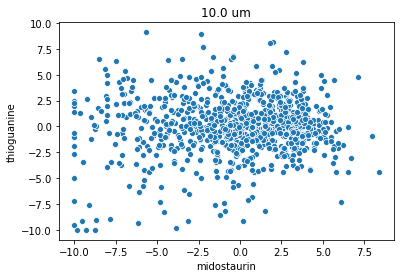

SpearmanrResult(correlation=-0.009804174674007553, pvalue=0.7594362914992197)


In [34]:
# compare midostaruin (1st column) to thiogaunine (3rd column)
spearman_correlation(sig_infos, 0, 2)

#### *2. Compare the gene signatures of different drugs targeting the different disease to each other*

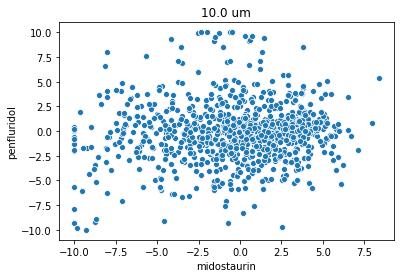

SpearmanrResult(correlation=0.09411124759856943, pvalue=0.003219990142334123)


In [35]:
# compare midostaruin (1st column) to penfluridol (2nd column)
spearman_correlation(sig_infos, 0, 1)

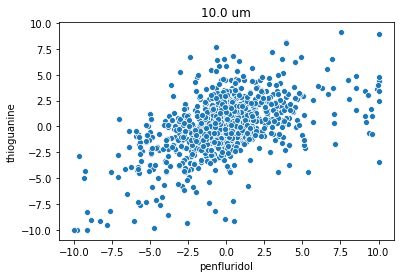

SpearmanrResult(correlation=0.49863240811967996, pvalue=1.3288137652223059e-62)


In [36]:
# compare penfluridol (2nd column) to thiogaunine (3rd column)
spearman_correlation(sig_infos, 1, 2)

## Selecting 3 different compounds to compare to each other

#### *1. Select 3 compounds to compare to each other*

In [37]:
# show disease areas of each drug
drug_to_disease['disease_area'][drug_to_disease.index.isin(cp_names)]

pert_iname
digoxin                                                        cardiology
lacidipine                                                     cardiology
ingenol-mebutate                                              dermatology
metronidazole                                                 dermatology
altrenogest                                                 endocrinology
lomitapide                                                  endocrinology
amsacrine                                          hematologic malignancy
midostaurin                                        hematologic malignancy
thioguanine                                        hematologic malignancy
daunorubicin                                       hematologic malignancy
tioguanine                                         hematologic malignancy
homoharringtonine                                  hematologic malignancy
romidepsin                                         hematologic malignancy
vorinostat                 

Let's compare amsacrine and midostaurin (hematologic malignancy, leukemia) to lacidipine (hypertension, cardiology)

#### *2. Select the relevant data for the 3 compounds to compare to each other*

In [38]:
# selecting compounds to compare data of
trt_cps = ['amsacrine', 'midostaurin', 'lacidipine']

In [39]:
# select the sig_info for these three compounds
test_cps_sig_info = high_tas_trt_cps[high_tas_trt_cps['pert_iname'].isin(trt_cps)]
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A010_MCF7_24H:I02,BRD-K13646352,midostaurin,MCF7,3.33 um,24 h,REP.A010_MCF7_24H_X1_B24:I02|REP.A010_MCF7_24H...,0.799386
REP.A010_MCF7_24H:I01,BRD-K13646352,midostaurin,MCF7,10.0 um,24 h,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H...,0.794343
REP.A007_MCF7_24H:B24,BRD-K43586850,lacidipine,MCF7,0.04 um,24 h,REP.A007_MCF7_24H_X1_B22:B24|REP.A007_MCF7_24H...,0.666125
REP.A023_MCF7_24H:D07,BRD-K68346641,amsacrine,MCF7,10.0 um,24 h,REP.A023_MCF7_24H_X1_B23:D07|REP.A023_MCF7_24H...,0.660436
REP.A007_MCF7_24H:B19,BRD-K43586850,lacidipine,MCF7,10.0 um,24 h,REP.A007_MCF7_24H_X1_B22:B19|REP.A007_MCF7_24H...,0.630512
REP.A007_MCF7_24H:B23,BRD-K43586850,lacidipine,MCF7,0.12 um,24 h,REP.A007_MCF7_24H_X1_B22:B23|REP.A007_MCF7_24H...,0.612047


In [40]:
# select only the 10.0 um
test_cps_sig_info = test_cps_sig_info[test_cps_sig_info['pert_idose'] == '10.0 um']
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A010_MCF7_24H:I01,BRD-K13646352,midostaurin,MCF7,10.0 um,24 h,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H...,0.794343
REP.A023_MCF7_24H:D07,BRD-K68346641,amsacrine,MCF7,10.0 um,24 h,REP.A023_MCF7_24H_X1_B23:D07|REP.A023_MCF7_24H...,0.660436
REP.A007_MCF7_24H:B19,BRD-K43586850,lacidipine,MCF7,10.0 um,24 h,REP.A007_MCF7_24H_X1_B22:B19|REP.A007_MCF7_24H...,0.630512


#### *3. Select the gene signatures for selected compounds*

In [41]:
# obtain all the different dosages
pert_idoses = test_cps_sig_info["pert_idose"].unique()

# initialize a list to store all the gene signatures and sig info for each dose in pert_idose
sig_infos = []

In [42]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# separate gene signatures by each dose in pert_idose
for dose in pert_idoses:
    # select gene signatures of one dose
    dose_sig_info = select_dose(test_cps_sig_info, dose)
    
    # select the gene signature ids
    dose_sig_ids = dose_sig_info.index
    
    # select only the landmark genes of drug compounds of interest
    dose_gene_sigs = parse(file_path, rid=lm_gene_id, cid=dose_sig_ids)
    
    # create a new GCTOO object that contains the sig_info as the columns and gene_sigs as rows
    sig_info = GCToo.GCToo(data_df=dose_gene_sigs.data_df.copy(), 
                                              row_metadata_df=dose_gene_sigs.row_metadata_df.copy(), 
                                              col_metadata_df=dose_sig_info, 
                                             make_multiindex=True)
    
    # store sig_info
    sig_infos.append(sig_info)

In [43]:
# snapshot of what each dataset looks like for each dose
sig_infos[0].multi_index_df[:5]

pert_id,BRD-K43586850,BRD-K13646352,BRD-K68346641
pert_iname,lacidipine,midostaurin,amsacrine
cell_id,MCF7,MCF7,MCF7
pert_idose,10.0 um,10.0 um,10.0 um
pert_itime,24 h,24 h,24 h
distil_id,REP.A007_MCF7_24H_X1_B22:B19|REP.A007_MCF7_24H_X2_B22:B19|REP.A007_MCF7_24H_X3.A2_B23:B19,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H_X2_B24:I01|REP.A010_MCF7_24H_X3_B24:I01,REP.A023_MCF7_24H_X1_B23:D07|REP.A023_MCF7_24H_X2_B23:D07|REP.A023_MCF7_24H_X3_B23:D07
tas,0.630512,0.794343,0.660436
cid,REP.A007_MCF7_24H:B19,REP.A010_MCF7_24H:I01,REP.A023_MCF7_24H:D07
rid,,,
0,-1.963299,1.669526,2.053771
1,-0.624348,3.920308,0.509816


### 4. Reperform Spearman Correlation

#### Compare similar drugs to each other

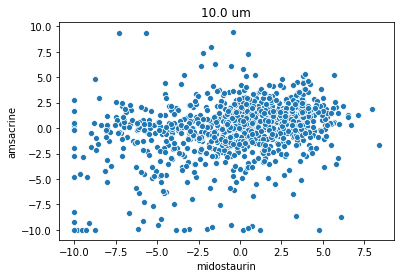

SpearmanrResult(correlation=0.2975557758223005, pvalue=1.9105761035606894e-21)


In [44]:
# compare midostaurin (2nd column) to amsacrine (3rd column)
spearman_correlation(sig_infos, 1, 2)

#### Compare different drugs targeting different diseases to each other

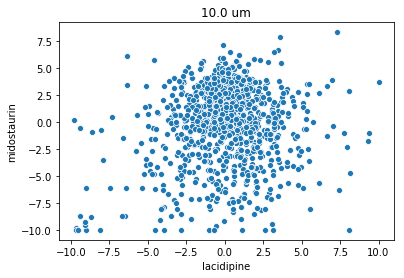

SpearmanrResult(correlation=0.03660843697605521, pvalue=0.2527171196913524)


In [45]:
# compare lacidipine (1st column) to midostaurin (2nd column)
spearman_correlation(sig_infos, 0, 1)

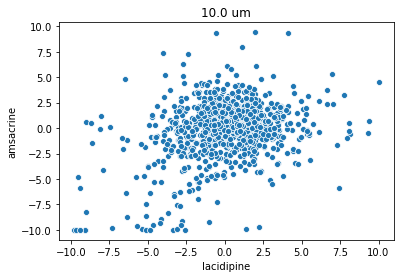

SpearmanrResult(correlation=0.1932565973061592, pvalue=1.1045761852894224e-09)


In [46]:
# compare lacidipine (1st column) to amsacrine (3rd column)
spearman_correlation(sig_infos, 0, 2)